In [1]:

from ultralytics import YOLO
from IPython.display import Image

In [2]:
import os

dataset_path = "label_data"

print("Dataset path:", dataset_path)
print("Classes:", os.listdir(dataset_path))

Dataset path: label_data
Classes: ['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'data.yaml', 'train']


In [3]:
!yolo task=detect mode=train \
  data="label_data/data.yaml" \
  model="yolo26n.pt" \
  epochs=50 \
  imgsz=416 \
  batch=16 \
  device=mps \
  patience=15 \
  cache=True \
  workers=4

New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.164 🚀 Python-3.10.11 torch-2.14.0 MPS (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=label_data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_

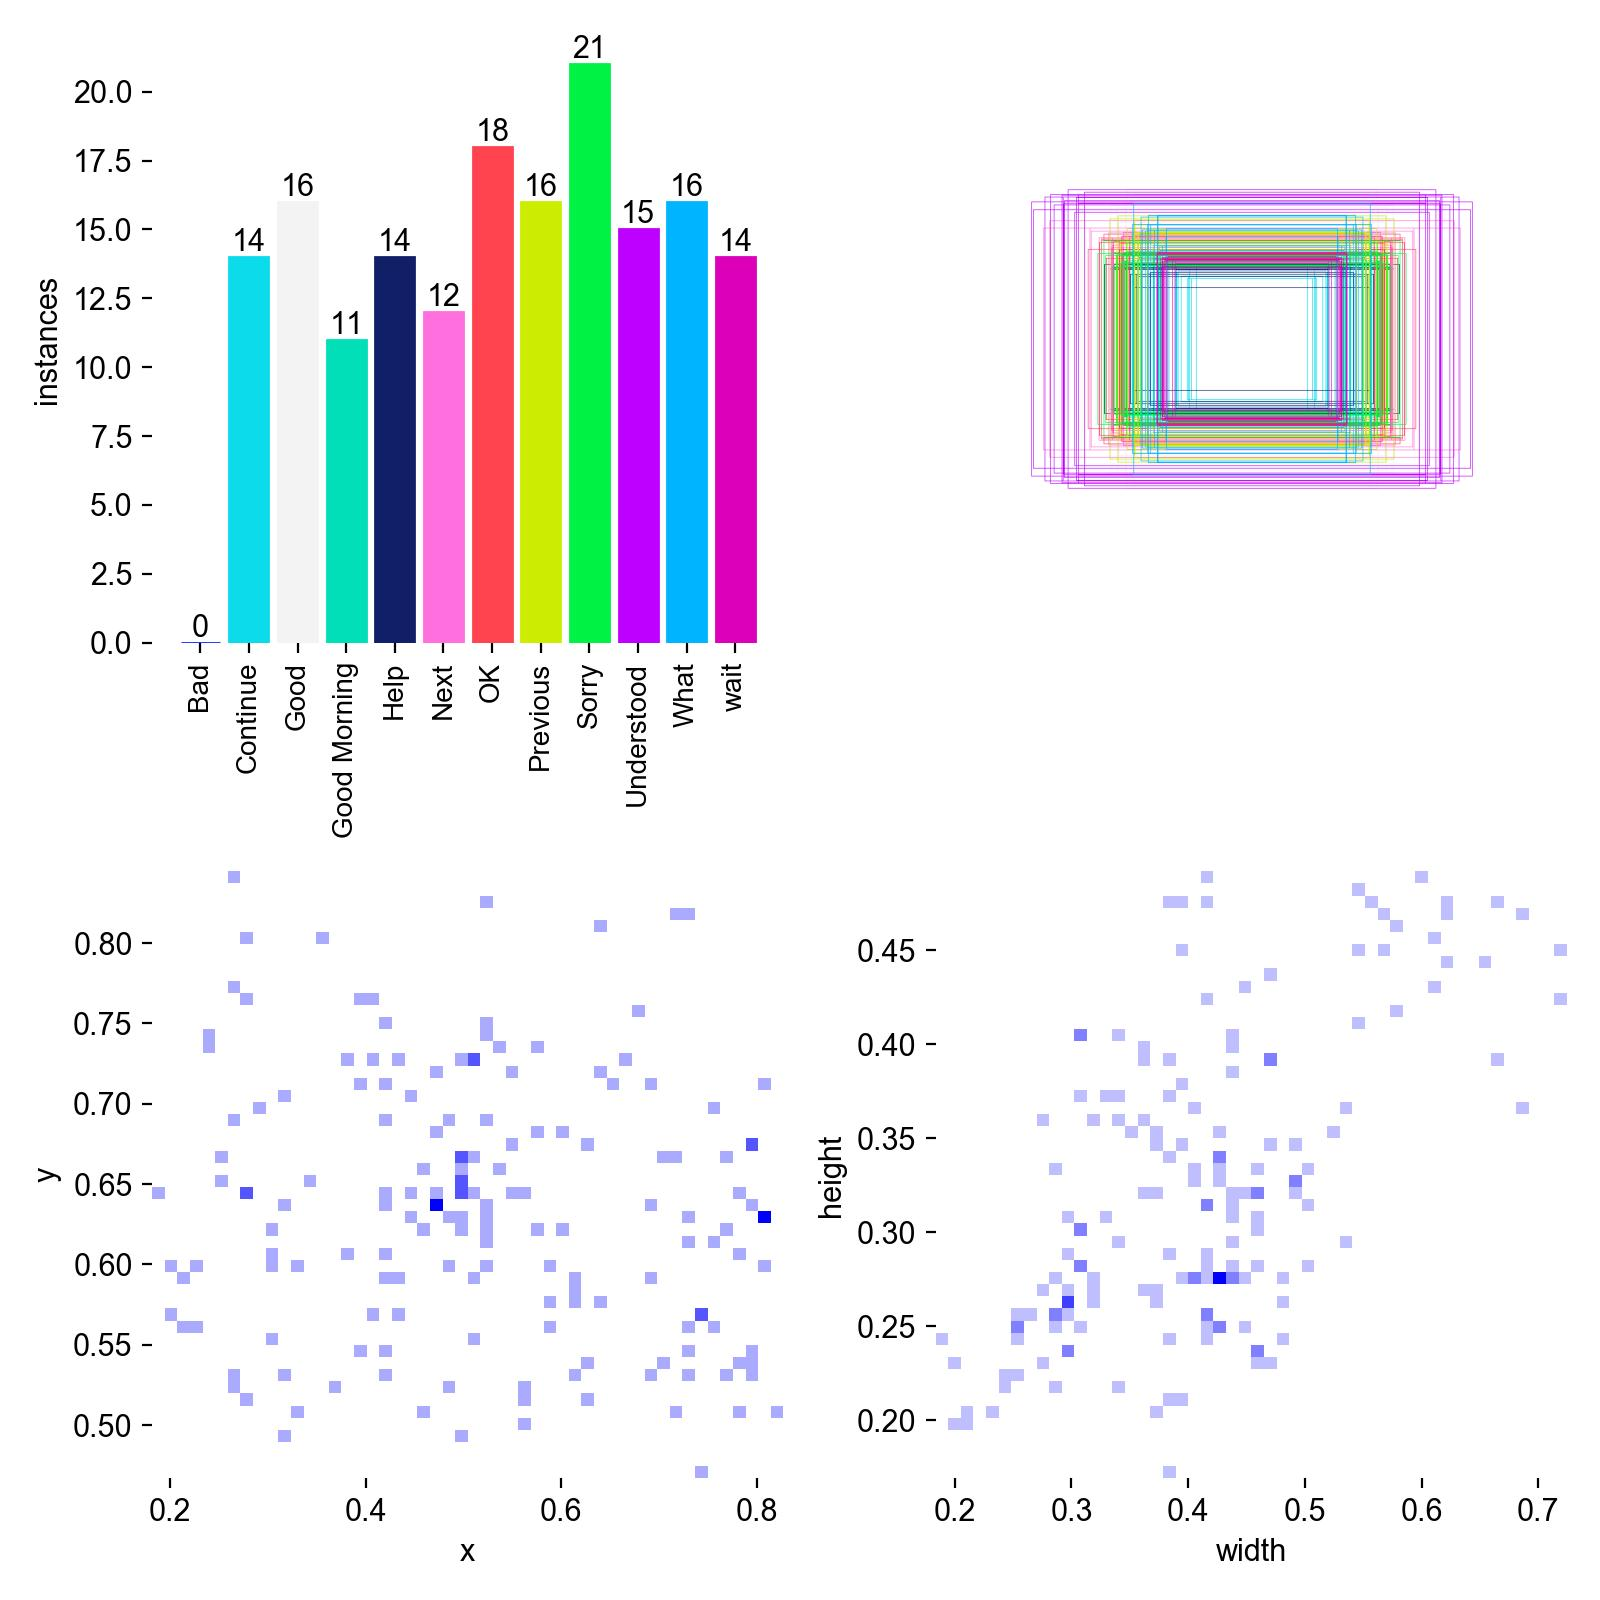

In [4]:
Image("runs/detect/train-5/labels.jpg", width=600)

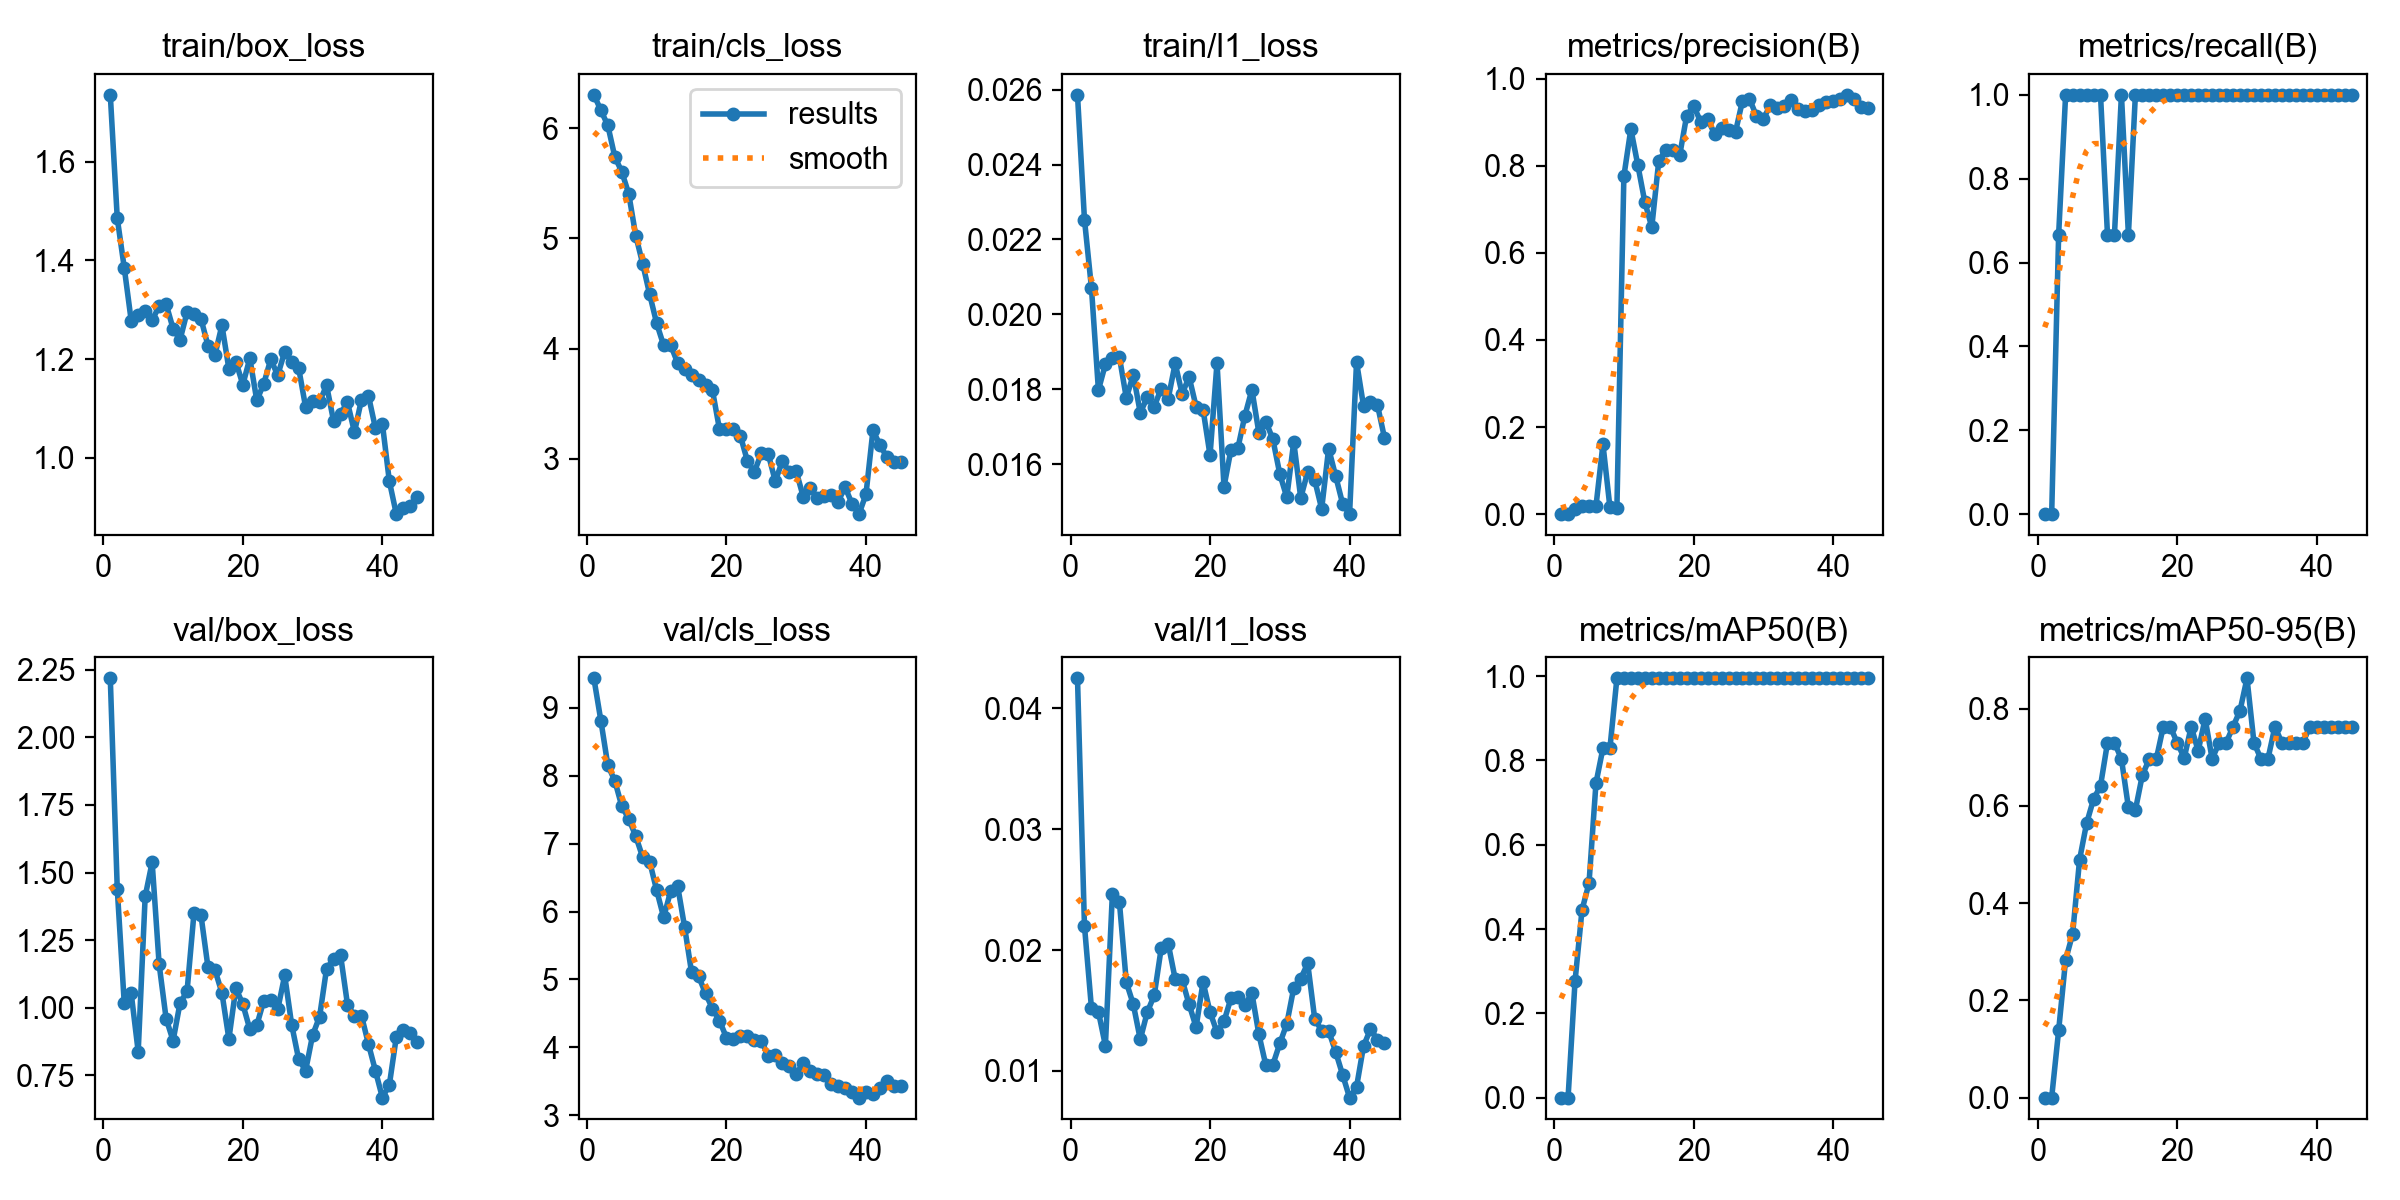

In [5]:

Image("runs/detect/train-5/results.png", width=600)

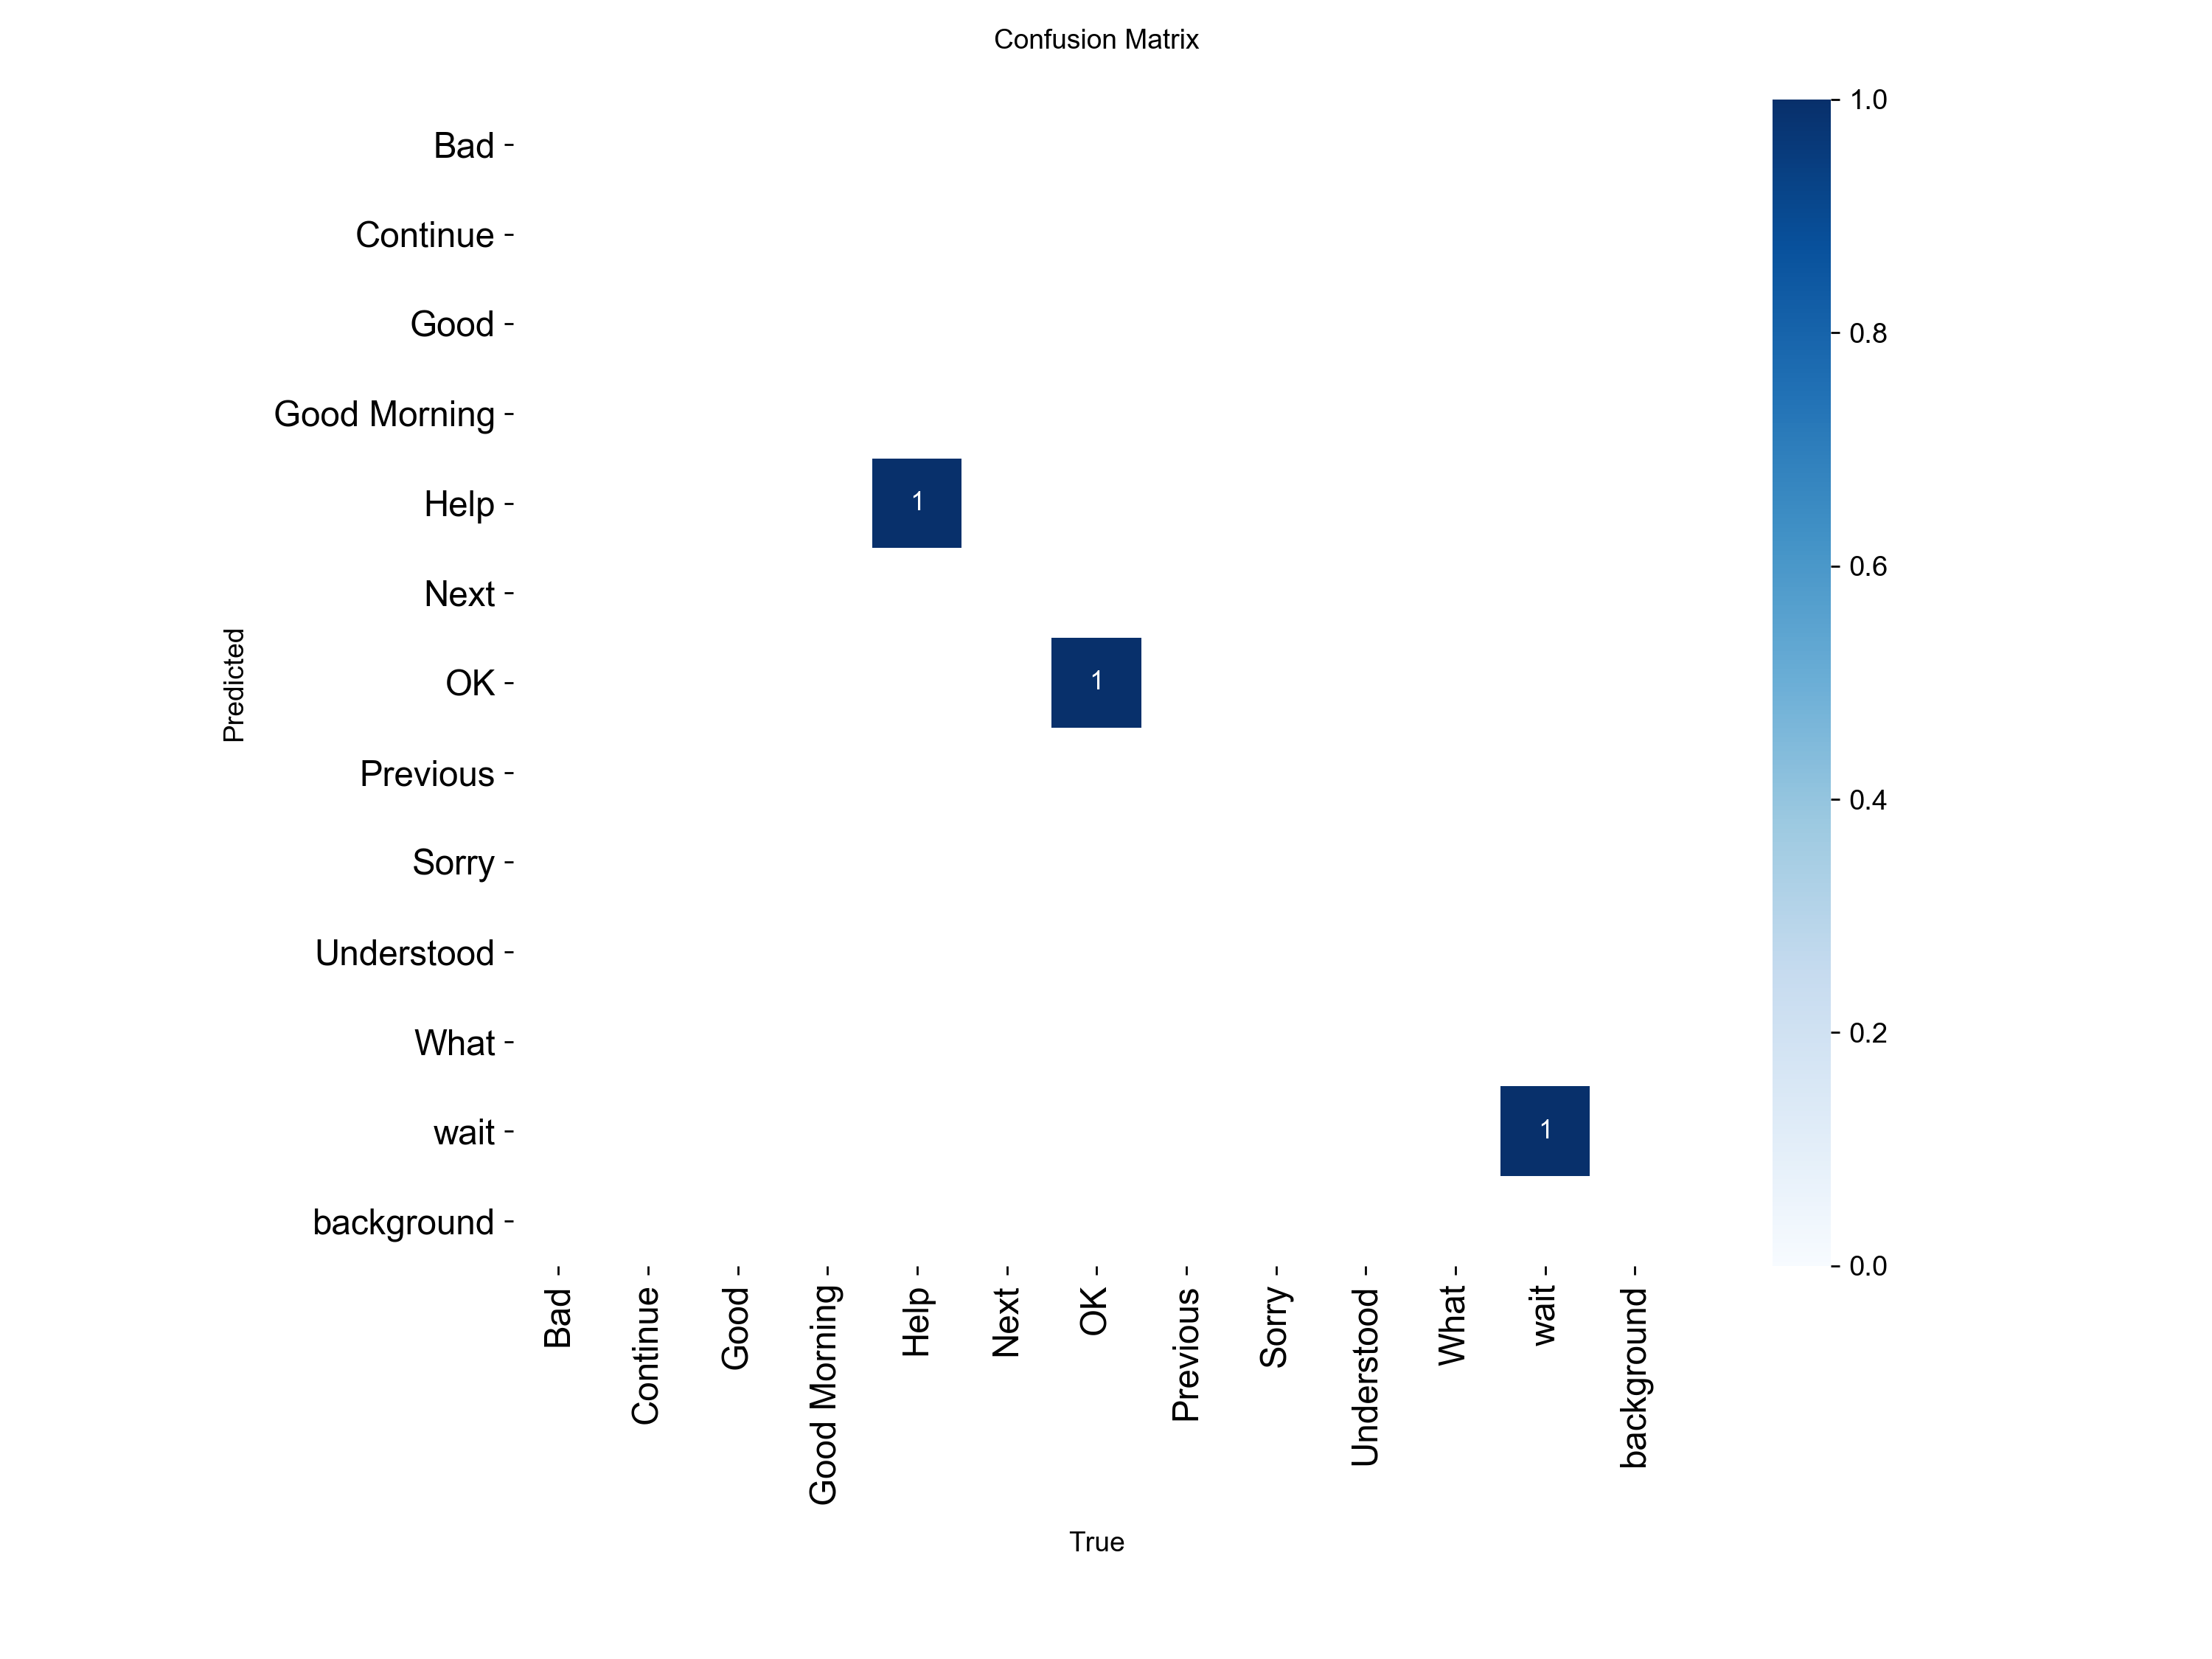

In [6]:
Image("runs/detect/train-5/confusion_matrix.png", width=600)

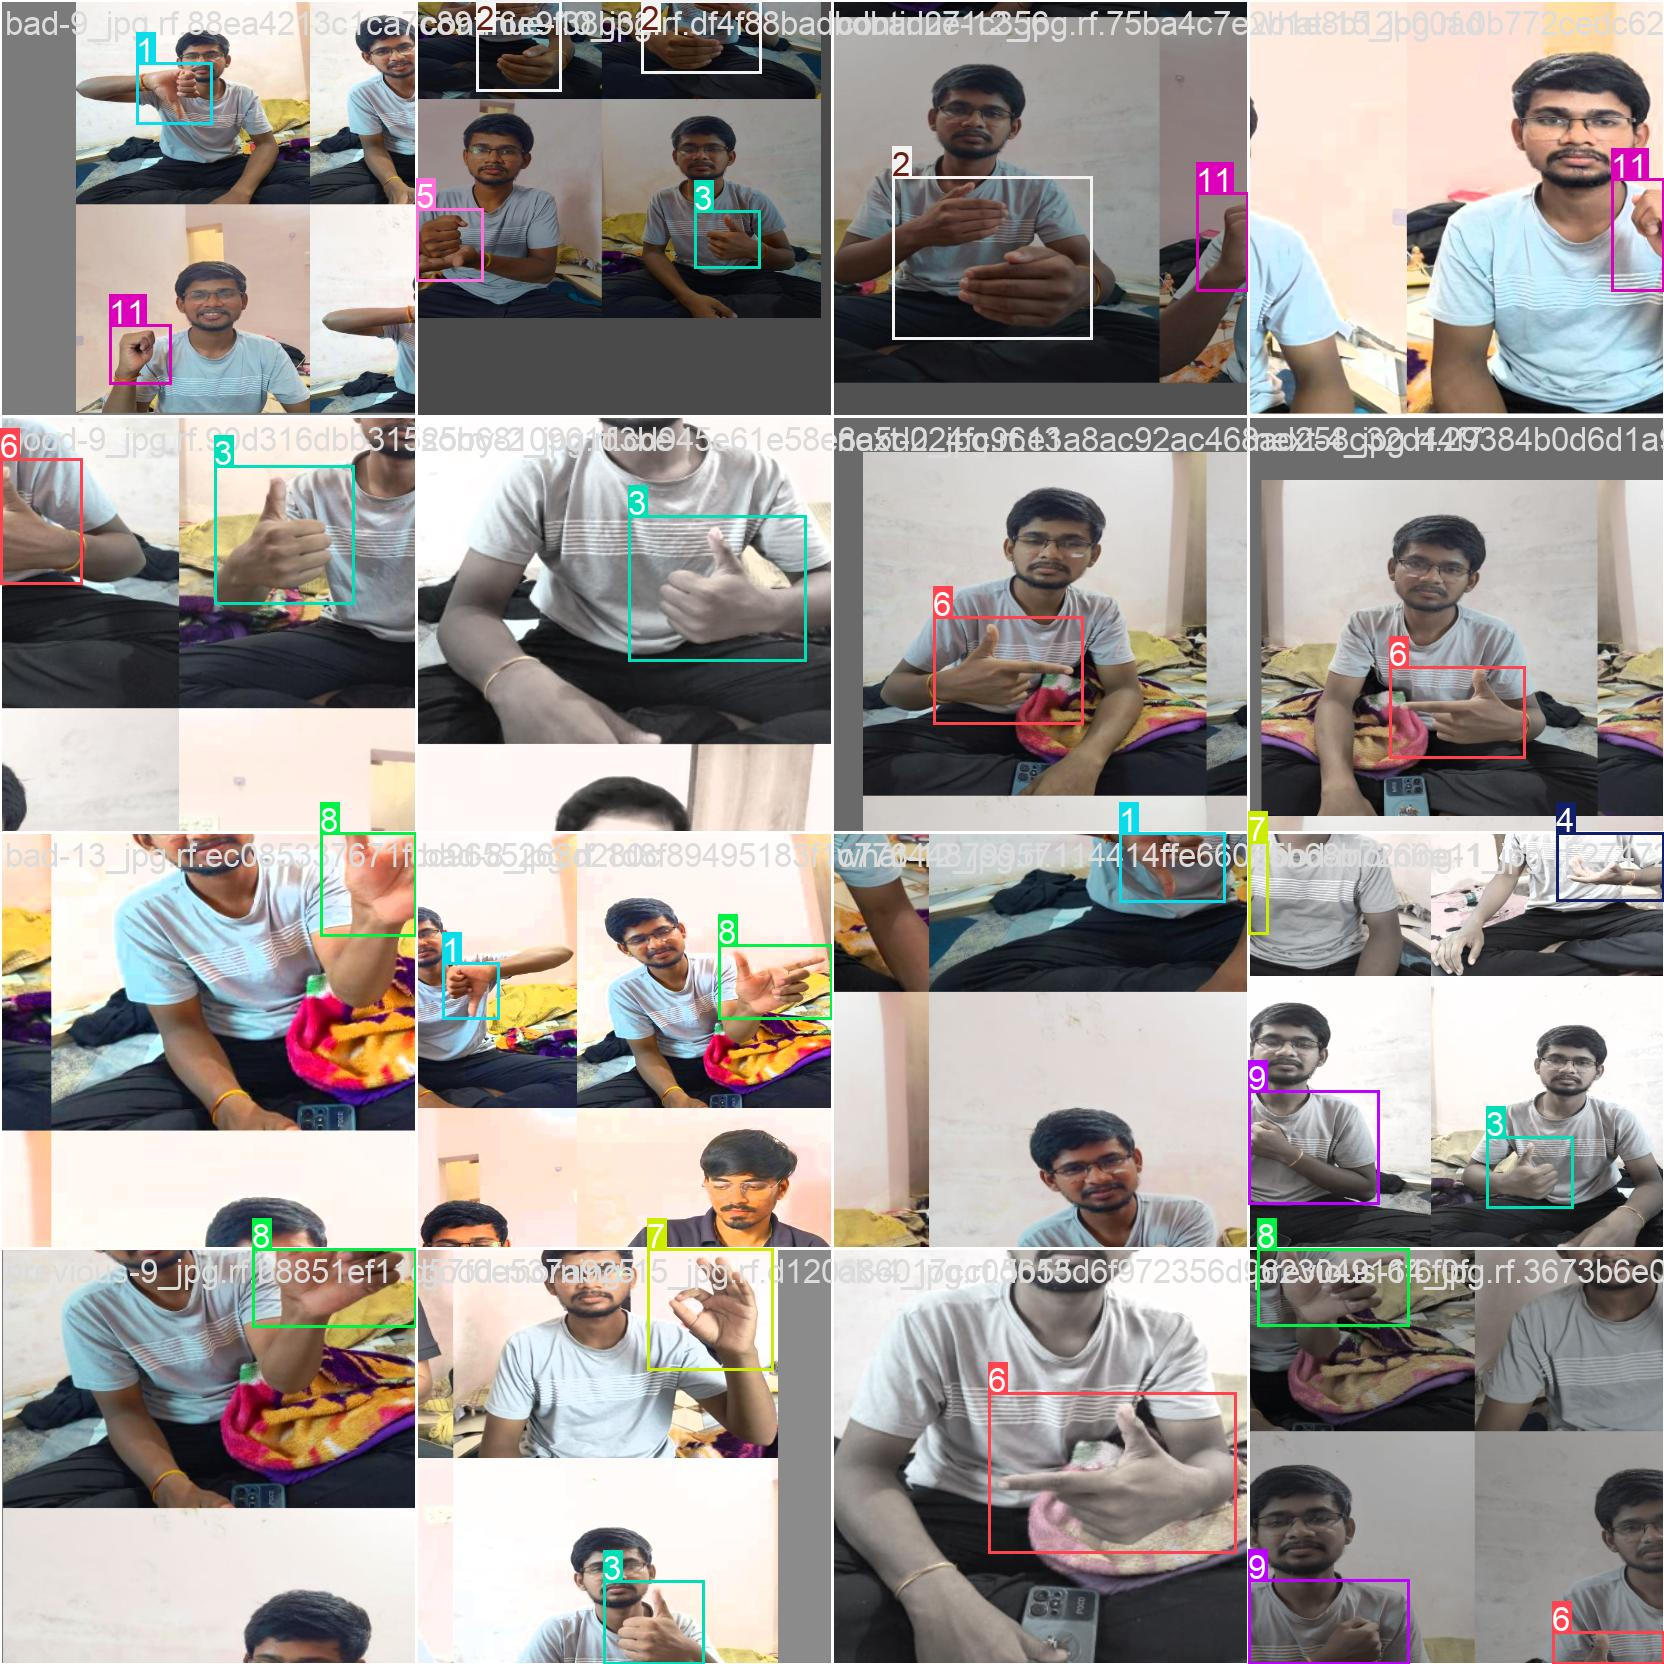

In [7]:

Image("runs/detect/train-5/train_batch0.jpg", width=600)

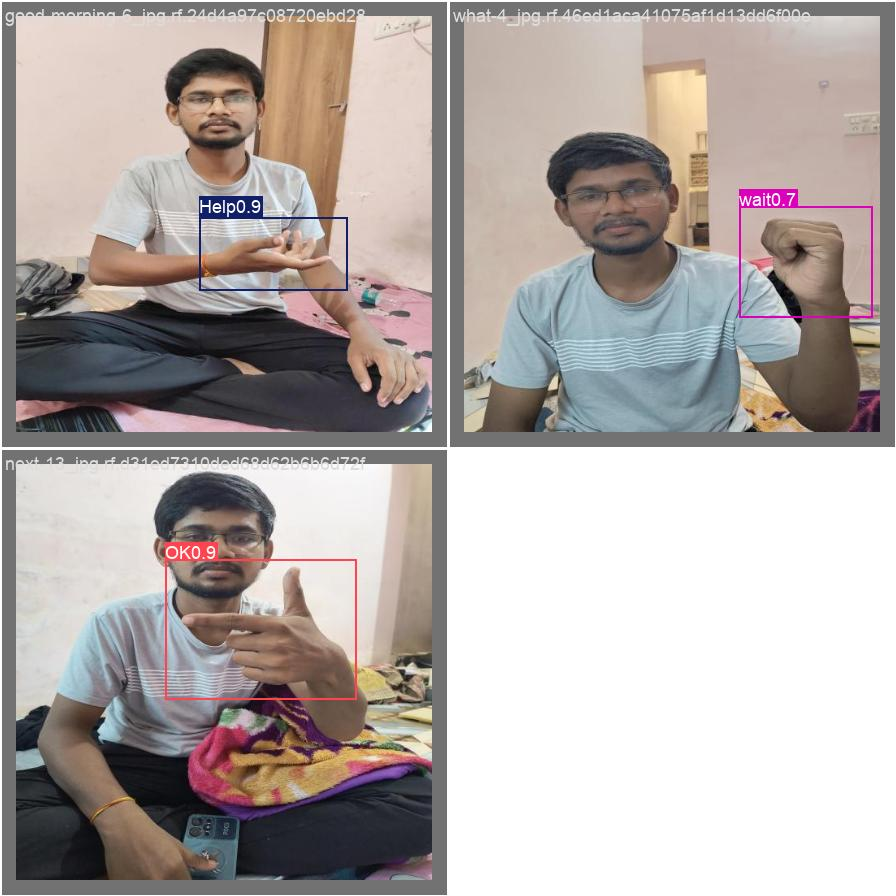

In [8]:
Image("runs/detect/train-5/val_batch0_pred.jpg", width=600)

In [9]:
#!yolo task=detect mode=predict model="runs/detect/train/weights/best.pt" conf=0.25 source="Sign_language_data/test/images" save=True

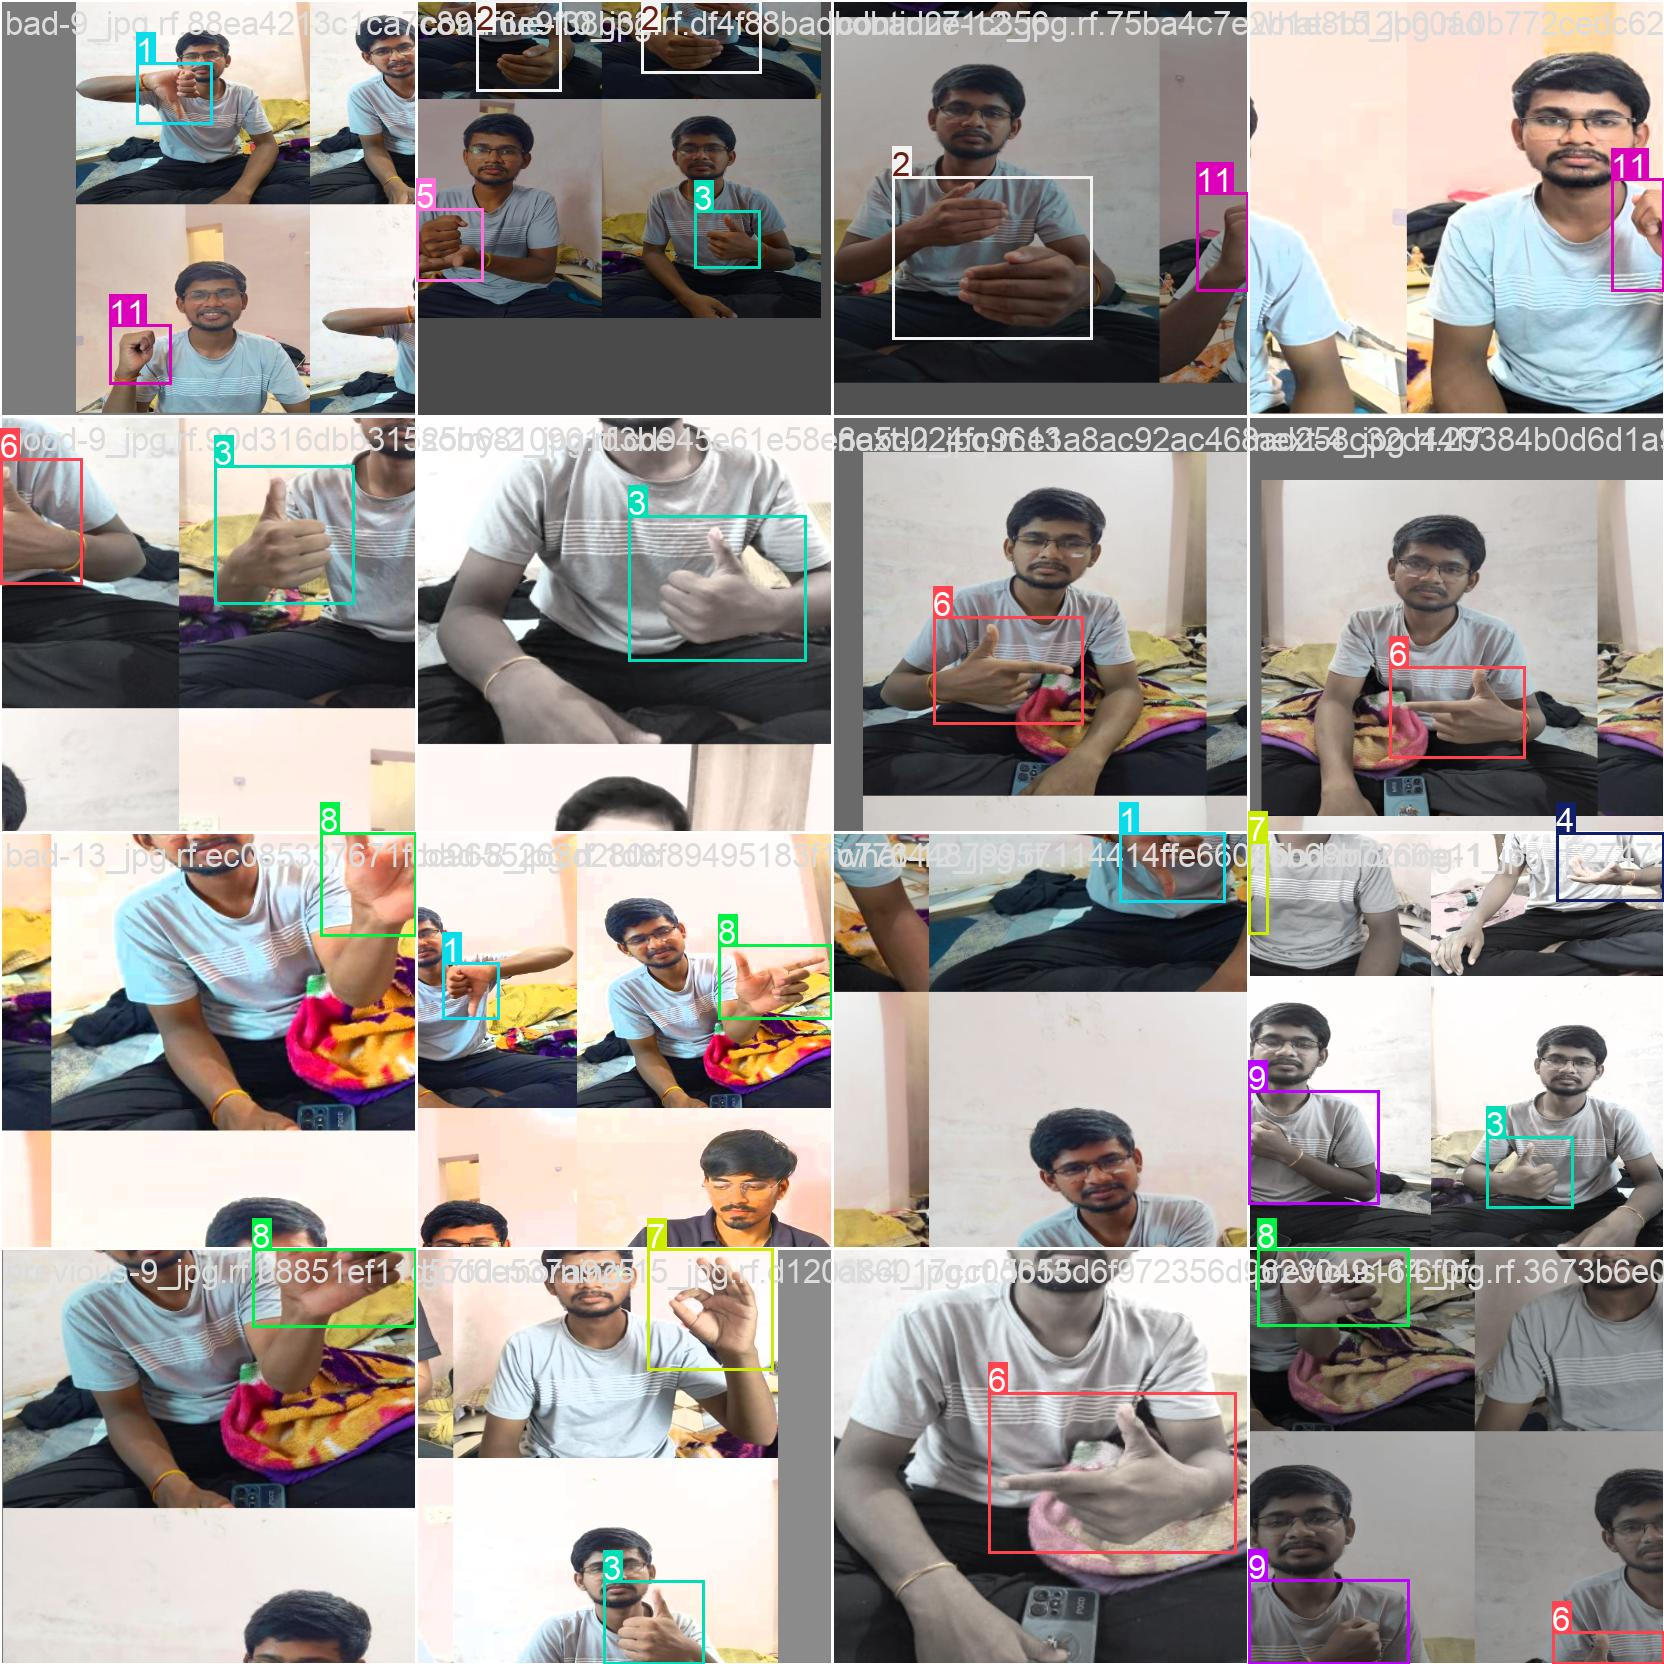

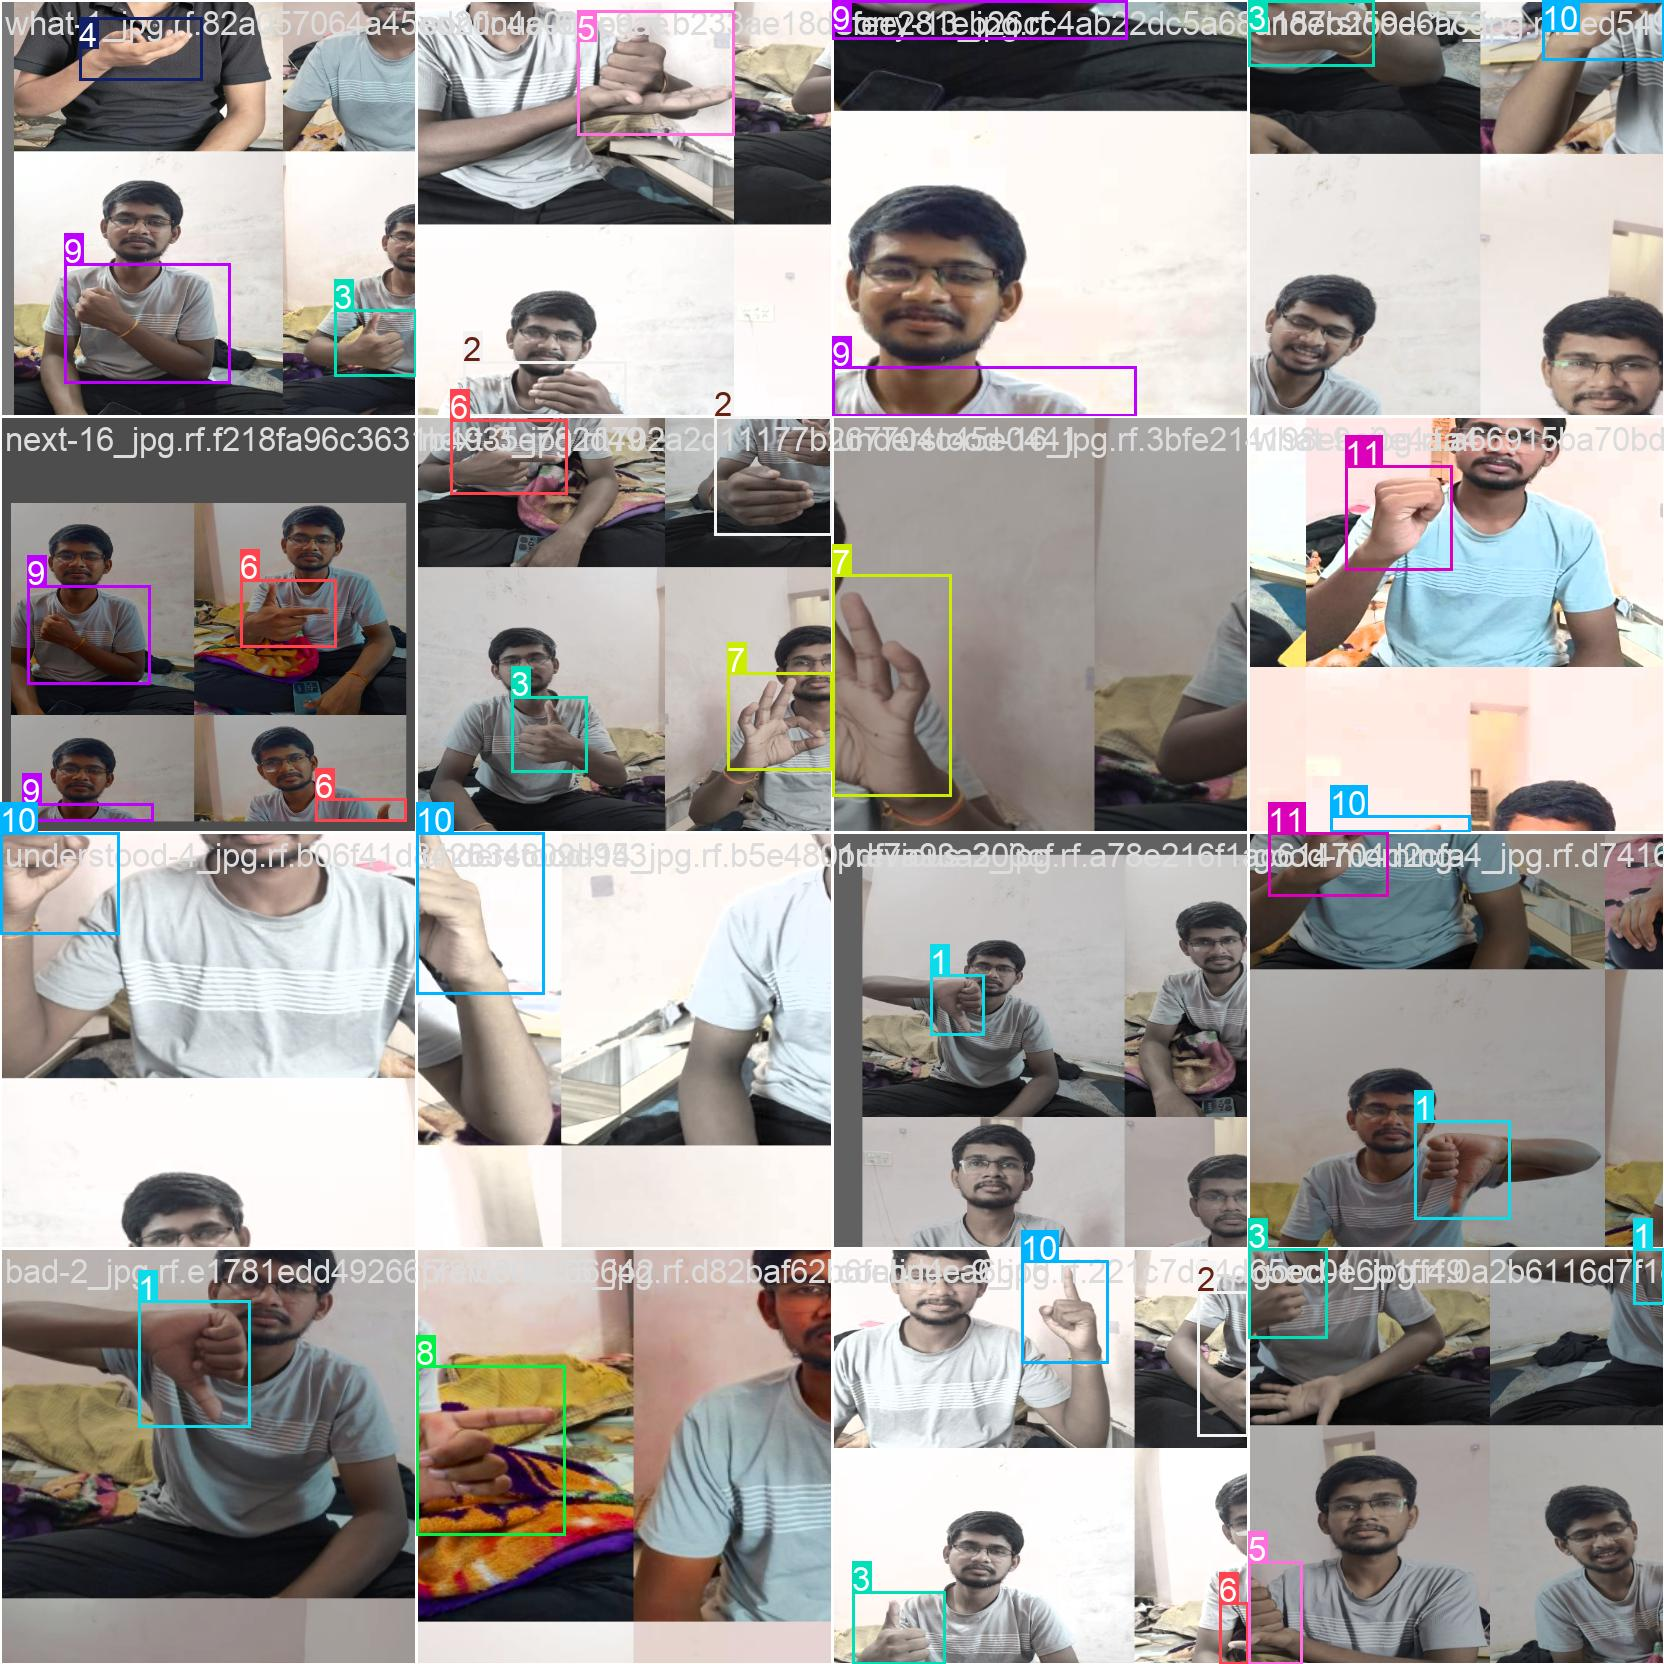

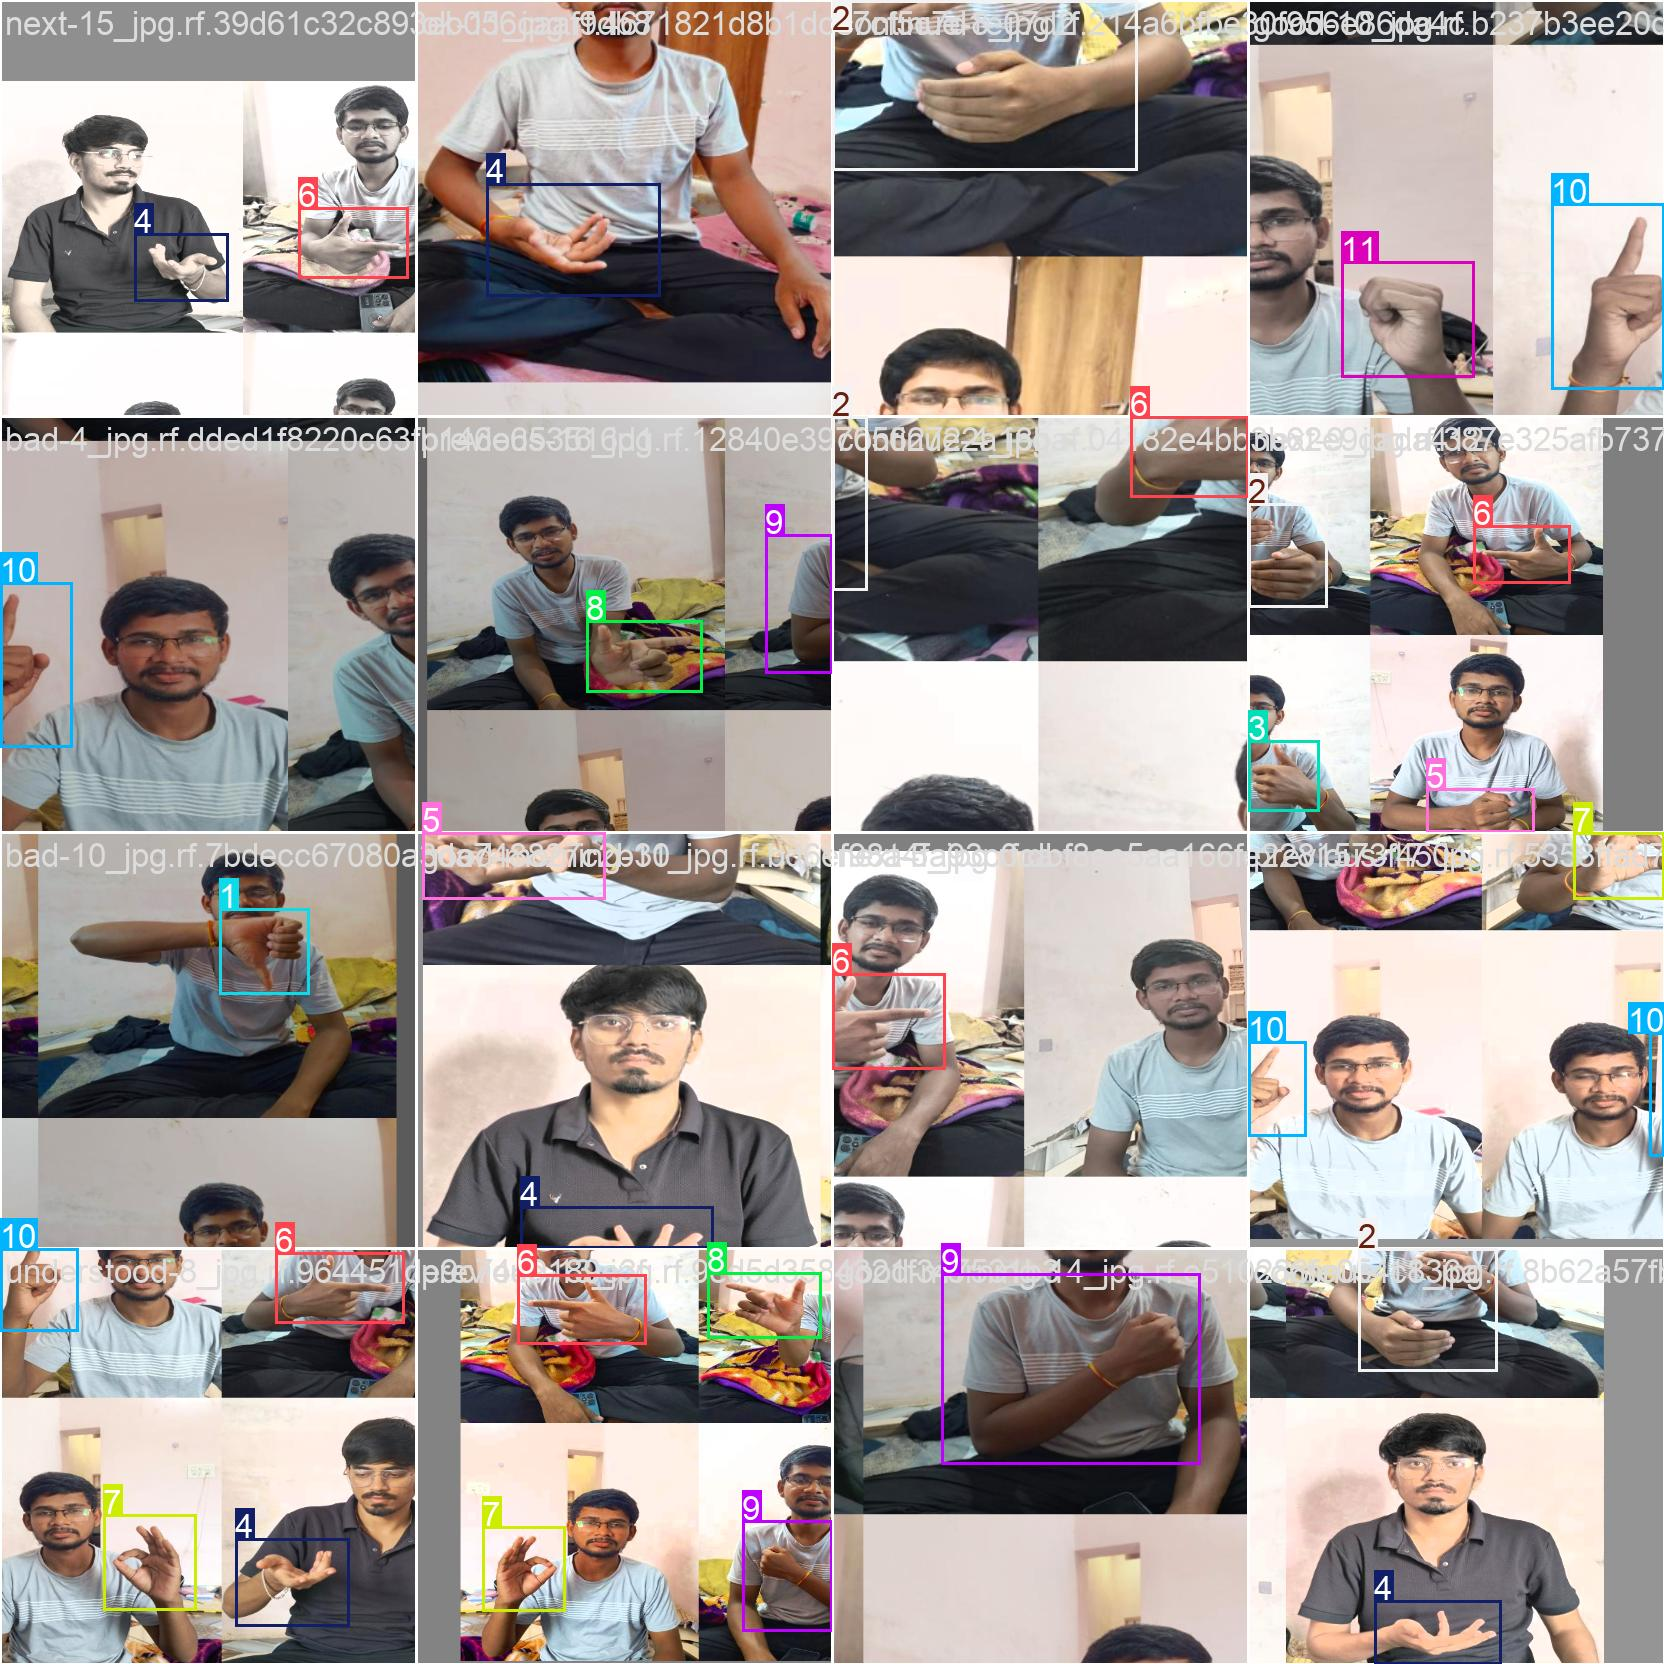

In [10]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('runs/detect/train-5'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [11]:
!yolo task=detect mode=predict model= "runs/detect/train-5/weights/best.pt" conf=0.25 source="label_data/test/images" save=True

Ultralytics 8.4.164 🚀 Python-3.10.11 torch-2.14.0 CPU (Apple M1)
YOLO26n summary (fused): 120 layers, 2,377,176 parameters, 0 gradients, 5.3 GFLOPs

image 1/20 /Users/mohitrohda/skill/Sign_language_detection/label_data/test/images/again-13_jpg.rf.2c868893552b25f3532548a68c2dbcdc.jpg: 416x416 (no detections), 26.0ms
image 2/20 /Users/mohitrohda/skill/Sign_language_detection/label_data/test/images/again-6_jpg.rf.a8b9ab72010db4e403abc6e5b5437160.jpg: 416x416 (no detections), 29.9ms
image 3/20 /Users/mohitrohda/skill/Sign_language_detection/label_data/test/images/again-9_jpg.rf.6d41588aacb58ccdfafc126a77eeeddd.jpg: 416x416 (no detections), 27.1ms
image 4/20 /Users/mohitrohda/skill/Sign_language_detection/label_data/test/images/good-13_jpg.rf.bc4df90f676d9b2c50cf625fa152aab1.jpg: 416x416 1 Good Morning, 29.0ms
image 5/20 /Users/mohitrohda/skill/Sign_language_detection/label_data/test/images/good-14_jpg.rf.0f5d78e4c14faf25a78922e9bfa7a5cd.jpg: 416x416 1 Good Morning, 29.0ms
image 6/20 /Users

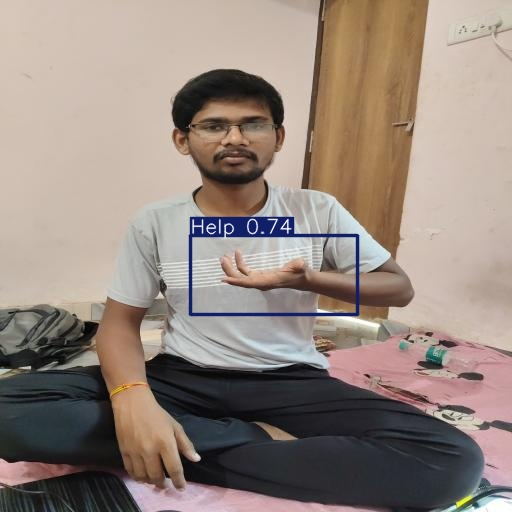

In [13]:
Image("runs/detect/predict-5/good-morning-9_jpg.rf.f9fa6ad02b9892f109e67dc08388c5dc.jpg", width=600)

In [3]:
#!yolo task=detect mode=predict model="runs/detect/train/weights/best.pt" conf=0.25 source=0 show=True

In [1]:
import cv2, subprocess, time, csv
from datetime import datetime
from ultralytics import YOLO

model = YOLO("runs/detect/train-4/weights/best.pt")

last_spoken, last_time, cooldown = None, 0, 2  


log_path = "detection_log.csv"
log_file = open(log_path, "w", newline="")
log_writer = csv.writer(log_file)
log_writer.writerow(["timestamp", "detected_sign", "confidence"])

cap = cv2.VideoCapture(1)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.25, verbose=False)
    annotated = results[0].plot()

    boxes = results[0].boxes
    if len(boxes) > 0:
        best = boxes[boxes.conf.argmax()]          
        label = model.names[int(best.cls[0])]
        conf = float(best.conf[0])

        now = time.time()
        if label != last_spoken or now - last_time > cooldown:
            subprocess.Popen(["say", label])       

            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            print(f"[{timestamp}] Detected: {label}  (conf: {conf:.2f})")   
            log_writer.writerow([timestamp, label, f"{conf:.2f}"])         
            log_file.flush()                                               

            last_spoken, last_time = label, now

    cv2.imshow("Sign Language Detection", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
log_file.close()
print(f"\nSession saved to {log_path}")


Session saved to detection_log.csv


OpenCV: out device of bound (0-0): 1
OpenCV: camera failed to properly initialize!


In [3]:
import cv2
import subprocess
import time
import csv
from datetime import datetime
from ultralytics import YOLO


# -----------------------------
# Load YOLO model
# -----------------------------
model = YOLO("runs/detect/train-4/weights/best.pt")
print("✅ YOLO model loaded")


# -----------------------------
# Speech cooldown
# -----------------------------
last_spoken = None
last_time = 0
cooldown = 2


# -----------------------------
# CSV logging
# -----------------------------
log_path = "detection_log.csv"

log_file = open(log_path, "w", newline="")
log_writer = csv.writer(log_file)

log_writer.writerow([
    "timestamp",
    "detected_sign",
    "confidence"
])


# -----------------------------
# Open camera
# -----------------------------
cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

if not cap.isOpened():
    print("❌ ERROR: Camera could not be opened.")
    print("Try VideoCapture(1) or check macOS Camera permissions.")
    log_file.close()
    exit()

print("✅ Camera opened successfully")


# -----------------------------
# Detection loop
# -----------------------------
while True:

    ret, frame = cap.read()

    if not ret:
        print("❌ Failed to read frame")
        break

    results = model.predict(
        frame,
        conf=0.25,
        verbose=False
    )

    annotated = results[0].plot()

    boxes = results[0].boxes

    if len(boxes) > 0:

        best_idx = boxes.conf.argmax().item()
        best = boxes[best_idx]

        label = model.names[int(best.cls.item())]
        conf = float(best.conf.item())

        now = time.time()

        if (
            label != last_spoken
            or now - last_time > cooldown
        ):

            # Speak detected sign
            subprocess.Popen(["say", label])

            timestamp = datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )

            print(
                f"[{timestamp}] "
                f"Detected: {label} "
                f"(conf: {conf:.2f})"
            )

            # Save log
            log_writer.writerow([
                timestamp,
                label,
                f"{conf:.2f}"
            ])

            log_file.flush()

            last_spoken = label
            last_time = now

    cv2.imshow(
        "Sign Language Detection",
        annotated
    )

    # Press Q to quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


# -----------------------------
# Cleanup
# -----------------------------
cap.release()
cv2.destroyAllWindows()
log_file.close()

print(f"\n✅ Session saved to {log_path}")

✅ YOLO model loaded
✅ Camera opened successfully
[2026-10-02 20:39:44] Detected: What (conf: 0.34)
[2026-10-02 20:39:46] Detected: What (conf: 0.33)
[2026-10-02 20:39:48] Detected: What (conf: 0.68)
[2026-10-02 20:39:50] Detected: wait (conf: 0.39)
[2026-10-02 20:40:00] Detected: What (conf: 0.39)
[2026-10-02 20:40:03] Detected: What (conf: 0.27)
[2026-10-02 20:40:08] Detected: Again (conf: 0.29)
[2026-10-02 20:40:08] Detected: Next (conf: 0.27)
[2026-10-02 20:40:08] Detected: Again (conf: 0.25)
[2026-10-02 20:40:09] Detected: Next (conf: 0.32)
[2026-10-02 20:40:09] Detected: Again (conf: 0.49)
[2026-10-02 20:40:09] Detected: Next (conf: 0.41)
[2026-10-02 20:40:11] Detected: Again (conf: 0.26)
[2026-10-02 20:40:11] Detected: Next (conf: 0.44)
[2026-10-02 20:40:11] Detected: Again (conf: 0.41)
[2026-10-02 20:40:11] Detected: Next (conf: 0.47)
[2026-10-02 20:40:12] Detected: Again (conf: 0.42)
[2026-10-02 20:40:13] Detected: Good Morning (conf: 0.31)
[2026-10-02 20:40:14] Detected: Again